## [[3,1,1]] Encoded Qubit Transport - Diagonal Edge Path

This notebook implements the **Diagonal Edge** transport path for the [[3,1,1]] repetition code on FakeBrisbane.

### Transport Configuration
- **Source cluster**: 58 - 71 - 77 (same as SmallEdge and LargeEdge)
- **Destination cluster**: 49 - 55 - 68
- **Travel path**: 78 → 79 → 80 → 81 → 82 → 83 → 84 → 85 → 73 → 66 → 67
- **Total SWAPs**: 42 (12 + 14 + 16) — **significantly more than SmallEdge (12) or LargeEdge (18)**

### Path Description
This is a **diagonal path** that:
1. Travels along row 8 (qubits 78-85)
2. Drops down via flag qubit 73 to row 6
3. Continues along row 6 (qubits 66-67) to reach destination

This tests the impact of **long-distance diagonal transport** on error rates.

In [1]:
import numpy as np
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')  # Reset to inline backend for notebooks
import matplotlib.pyplot as plt
import rustworkx as rx
from rustworkx.visualization import mpl_draw
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeBrisbane
from qiskit_aer import AerSimulator

# Load Backend
backend = FakeBrisbane()
coupling_map = backend.coupling_map
print(f"Loaded backend: {backend.name} with {backend.num_qubits} qubits")

Loaded backend: fake_brisbane with 127 qubits


## 1. Verify Topology & Connectivity

Before building the circuit, we must verify:
- **Source cluster (58, 71, 77)**: Is qubit 71 connected to both 58 and 77?
- **Destination cluster (49, 55, 68)**: Is qubit 55 connected to both 49 and 68?
- **Syndrome ancillas (50, 69)**: 
  - Ancilla 50 → needs to access qubits 49 and 55 for $Z_{49}Z_{55}$ parity
  - Ancilla 69 → needs to access qubits 55 and 68 for $Z_{55}Z_{68}$ parity

In [2]:
# Define Qubit Roles - Diagonal Edge Path
# Source: 58 - 71 - 77 (data at 71, ancillas at 58 and 77)
# Destination: 49 - 55 - 68 (data arrives at 55)
# Syndrome Ancillas: 50 (for top pair 49-55), 69 (for bottom pair 55-68)

source_qubits = [58, 71, 77]  # [top, data, bottom]
dest_qubits = [49, 55, 68]    # [top', data', bottom']
ancilla_qubits = [50, 69]     # Syndrome measurement ancillas [top_ancilla, bottom_ancilla]
travel_path = [78, 79, 80, 81, 82, 83, 84, 85, 73, 66, 67]

# Extract individual qubits for clarity
src_top, src_data, src_bot = source_qubits
dst_top, dst_data, dst_bot = dest_qubits
anc_top, anc_bot = ancilla_qubits

def check_connection(u, v):
    """Returns True if physical wire exists between u and v."""
    return u in coupling_map.neighbors(v) or v in coupling_map.neighbors(u)

print(f"=== Checking Topology on {backend.name} ===\n")

# A. Source Check - Data qubit must connect to encoding ancillas
valid_src_1 = check_connection(src_data, src_top)
valid_src_2 = check_connection(src_data, src_bot)
print(f"SOURCE ({src_top} - {src_data} - {src_bot}):")
print(f"  {src_data}-{src_top} connected? {valid_src_1}")
print(f"  {src_data}-{src_bot} connected? {valid_src_2}")
if valid_src_1 and valid_src_2:
    print("  ✓ Source cluster is VALID")
else:
    print("  ⚠️ Source cluster has connectivity issues!")

# B. Destination Check - Center qubit must connect to neighbors
valid_dst_1 = check_connection(dst_data, dst_top)
valid_dst_2 = check_connection(dst_data, dst_bot)
print(f"\nDESTINATION ({dst_top} - {dst_data} - {dst_bot}):")
print(f"  {dst_data}-{dst_top} connected? {valid_dst_1}")
print(f"  {dst_data}-{dst_bot} connected? {valid_dst_2}")
if valid_dst_1 and valid_dst_2:
    print("  ✓ Destination cluster is VALID")
else:
    print("  ⚠️ Destination cluster has connectivity issues!")

# C. Syndrome Ancilla Check (Critical!)
# Top ancilla needs to reach BOTH dst_top and dst_data for Z parity
# Bottom ancilla needs to reach BOTH dst_data and dst_bot for Z parity
s1_check_anc_top = check_connection(anc_top, dst_top)
s1_check_anc_data = check_connection(anc_top, dst_data)
s2_check_anc_data = check_connection(anc_bot, dst_data)
s2_check_anc_bot = check_connection(anc_bot, dst_bot)

print(f"\nSYNDROME ANCILLAS:")
print(f"  Ancilla {anc_top} (for Z_{dst_top}Z_{dst_data}):")
print(f"    {anc_top}-{dst_top} connected? {s1_check_anc_top}")
print(f"    {anc_top}-{dst_data} connected? {s1_check_anc_data}")
print(f"    → Direct syndrome? {s1_check_anc_top and s1_check_anc_data}")

print(f"  Ancilla {anc_bot} (for Z_{dst_data}Z_{dst_bot}):")
print(f"    {anc_bot}-{dst_data} connected? {s2_check_anc_data}")
print(f"    {anc_bot}-{dst_bot} connected? {s2_check_anc_bot}")
print(f"    → Direct syndrome? {s2_check_anc_data and s2_check_anc_bot}")

# D. Verify Travel Path Connectivity
print(f"\n=== TRAVEL PATH VERIFICATION ===")
full_path = [src_bot] + travel_path + [dst_bot]
print(f"Full path for bottom qubit: {' → '.join(map(str, full_path))}")
path_valid = True
for i in range(len(full_path) - 1):
    connected = check_connection(full_path[i], full_path[i+1])
    if not connected:
        print(f"  ⚠️ {full_path[i]}-{full_path[i+1]} NOT connected!")
        path_valid = False
if path_valid:
    print(f"  ✓ All {len(full_path)-1} edges in path are connected!")

# Summary
print("\n=== CONNECTIVITY SUMMARY ===")
if not (s1_check_anc_top and s1_check_anc_data):
    print(f"  ⚠️ Ancilla {anc_top} cannot directly measure Z_{dst_top}Z_{dst_data} → Need SWAP-assisted syndrome")
if not (s2_check_anc_data and s2_check_anc_bot):
    print(f"  ⚠️ Ancilla {anc_bot} cannot directly measure Z_{dst_data}Z_{dst_bot} → Need SWAP-assisted syndrome")

=== Checking Topology on fake_brisbane ===

SOURCE (58 - 71 - 77):
  71-58 connected? True
  71-77 connected? True
  ✓ Source cluster is VALID

DESTINATION (49 - 55 - 68):
  55-49 connected? True
  55-68 connected? True
  ✓ Destination cluster is VALID

SYNDROME ANCILLAS:
  Ancilla 50 (for Z_49Z_55):
    50-49 connected? True
    50-55 connected? False
    → Direct syndrome? False
  Ancilla 69 (for Z_55Z_68):
    69-55 connected? False
    69-68 connected? True
    → Direct syndrome? False

=== TRAVEL PATH VERIFICATION ===
Full path for bottom qubit: 77 → 78 → 79 → 80 → 81 → 82 → 83 → 84 → 85 → 73 → 66 → 67 → 68
  ✓ All 12 edges in path are connected!

=== CONNECTIVITY SUMMARY ===
  ⚠️ Ancilla 50 cannot directly measure Z_49Z_55 → Need SWAP-assisted syndrome
  ⚠️ Ancilla 69 cannot directly measure Z_55Z_68 → Need SWAP-assisted syndrome


## 2. Visualize the Layout

Let's visualize the source, destination, and the diagonal transport path on the chip topology.

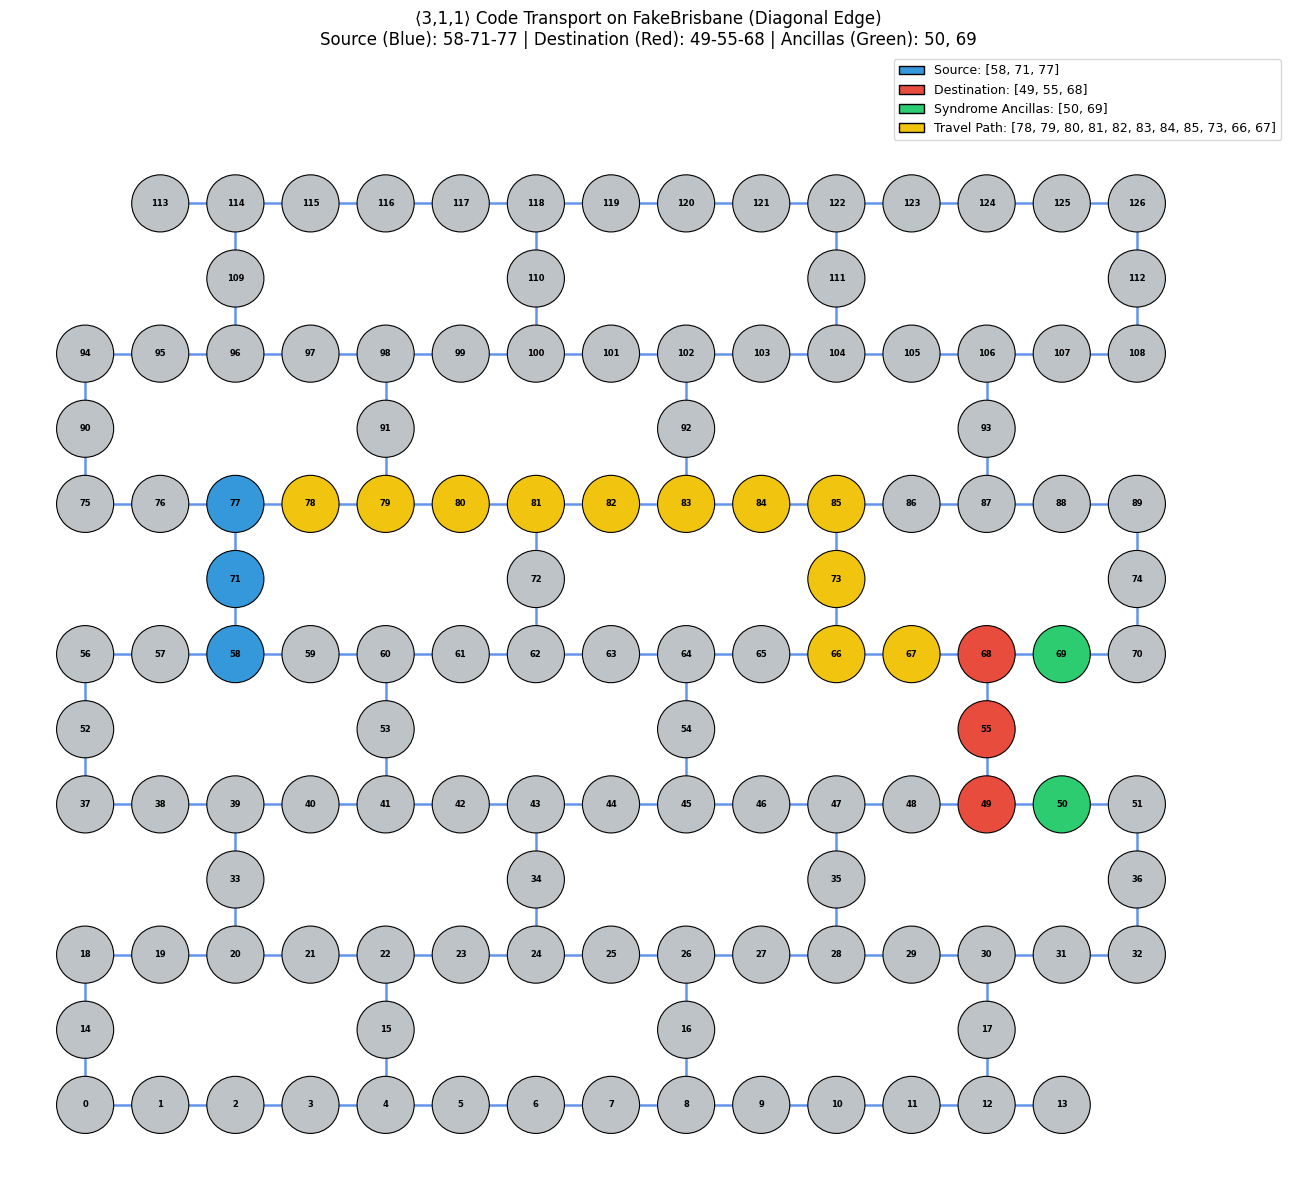


=== Transport Paths (Diagonal Edge - 42 SWAPs total) ===
  77 → 68: 77→78→79→80→81→82→83→84→85→73→66→67→68 (12 SWAPs)
  71 → 55: 71→77→78→79→80→81→82→83→84→85→73→66→67→68→55 (14 SWAPs)
  58 → 49: 58→71→77→78→79→80→81→82→83→84→85→73→66→67→68→55→49 (16 SWAPs)

This is 3.5x more SWAPs than SmallEdge (12) and 2.3x more than LargeEdge (18)!


In [3]:
# Build custom Heavy Hex visualization with positions derived from actual connectivity
from matplotlib.patches import Patch

edges = list(coupling_map.get_edges())

# Build adjacency
adj = {i: set() for i in range(127)}
for e in edges:
    adj[e[0]].add(e[1])
    adj[e[1]].add(e[0])

# Heavy Hex layout: main rows are horizontal, flag qubits connect vertically
pos = {}

# Row 0 (y=0): qubits 0-13  
for i, q in enumerate([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]):
    pos[q] = (i, 0)

# Flag row 1 (y=1): 14,15,16,17
pos[14] = (0, 1)
pos[15] = (4, 1)
pos[16] = (8, 1)
pos[17] = (12, 1)

# Row 2 (y=2): qubits 18-32
for i, q in enumerate([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]):
    pos[q] = (i, 2)

# Flag row 3 (y=3): 33,34,35,36
pos[33] = (2, 3)
pos[34] = (6, 3)
pos[35] = (10, 3)
pos[36] = (14, 3)

# Row 4 (y=4): 37-51
for i, q in enumerate([37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]):
    pos[q] = (i, 4)

# Flag row 5 (y=5): 52,53,54,55
pos[52] = (0, 5)
pos[53] = (4, 5)
pos[54] = (8, 5)
pos[55] = (12, 5)

# Row 6 (y=6): 56-70
for i, q in enumerate([56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70]):
    pos[q] = (i, 6)

# Flag row 7 (y=7): 71,72,73,74
pos[71] = (2, 7)
pos[72] = (6, 7)
pos[73] = (10, 7)
pos[74] = (14, 7)

# Row 8 (y=8): 75-89
for i, q in enumerate([75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89]):
    pos[q] = (i, 8)

# Flag row 9 (y=9): 90,91,92,93
pos[90] = (0, 9)
pos[91] = (4, 9)
pos[92] = (8, 9)
pos[93] = (12, 9)

# Row 10 (y=10): 94-108
for i, q in enumerate([94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108]):
    pos[q] = (i, 10)

# Flag row 11 (y=11): 109,110,111,112
pos[109] = (2, 11)
pos[110] = (6, 11)
pos[111] = (10, 11)
pos[112] = (14, 11)

# Row 12 (y=12): 113-126
for i, q in enumerate([113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]):
    pos[q] = (i + 1, 12)

# Color nodes by role
node_colors = {}
for i in range(backend.num_qubits):
    if i in source_qubits: 
        node_colors[i] = '#3498db'  # Blue (Source)
    elif i in dest_qubits: 
        node_colors[i] = '#e74c3c'  # Red (Destination)
    elif i in ancilla_qubits:
        node_colors[i] = '#2ecc71'  # Green (Syndrome Ancillas)
    elif i in travel_path:
        node_colors[i] = '#f1c40f'  # Yellow (Travel Path)  
    else: 
        node_colors[i] = '#bdc3c7'  # Light Gray

# Create figure
fig, ax = plt.subplots(figsize=(18, 12))

# Draw edges
for edge in edges:
    q0, q1 = edge[0], edge[1]
    if q0 in pos and q1 in pos:
        x0, y0 = pos[q0]
        x1, y1 = pos[q1]
        ax.plot([x0, x1], [y0, y1], 'cornflowerblue', linewidth=1.8, zorder=1)

# Draw nodes
node_radius = 0.38
for i in range(backend.num_qubits):
    if i in pos:
        x, y = pos[i]
        circle = plt.Circle((x, y), node_radius, color=node_colors[i], ec='black', linewidth=0.8, zorder=2)
        ax.add_patch(circle)
        ax.text(x, y, str(i), ha='center', va='center', fontsize=6, fontweight='bold', zorder=3)

ax.set_xlim(-1, 16)
ax.set_ylim(-1, 14)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("⟨3,1,1⟩ Code Transport on FakeBrisbane (Diagonal Edge)\nSource (Blue): 58-71-77 | Destination (Red): 49-55-68 | Ancillas (Green): 50, 69", fontsize=12)

legend_elements = [
    Patch(facecolor='#3498db', edgecolor='black', label=f'Source: {source_qubits}'),
    Patch(facecolor='#e74c3c', edgecolor='black', label=f'Destination: {dest_qubits}'),
    Patch(facecolor='#2ecc71', edgecolor='black', label=f'Syndrome Ancillas: {ancilla_qubits}'),
    Patch(facecolor='#f1c40f', edgecolor='black', label=f'Travel Path: {travel_path}'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

# Show the transport paths
print("\n=== Transport Paths (Diagonal Edge - 42 SWAPs total) ===")
print("  77 → 68: 77→78→79→80→81→82→83→84→85→73→66→67→68 (12 SWAPs)")
print("  71 → 55: 71→77→78→79→80→81→82→83→84→85→73→66→67→68→55 (14 SWAPs)")
print("  58 → 49: 58→71→77→78→79→80→81→82→83→84→85→73→66→67→68→55→49 (16 SWAPs)")
print("\nThis is 3.5x more SWAPs than SmallEdge (12) and 2.3x more than LargeEdge (18)!")

## 3. Build the Quantum Circuit

The circuit has 3 stages for the **Diagonal Edge** transport path:

1. **Encoding** (at source 58-71-77): 
   - Prepare $|+\rangle$ on data qubit 71
   - CNOT to 58 and 77 → creates $|+\rangle_L = (|000\rangle + |111\rangle)/\sqrt{2}$

2. **Transport** (SWAP chains - diagonal path via row 8 and flag 73): 
   - Move 77 → 68 (12 SWAPs) - bottom qubit
   - Move 71 → 55 (14 SWAPs) - data qubit  
   - Move 58 → 49 (16 SWAPs) - top qubit
   - **Total: 42 SWAPs** (vs 12 in SmallEdge, 18 in LargeEdge)

3. **SWAP-Assisted Syndrome Measurement**:
   - Since ancillas don't directly connect to all data qubits, use **SWAP-CNOT-SWAP** pattern
   - Syndrome 1: CNOT(49→50), SWAP(55↔49), CNOT(49→50), SWAP back
   - Syndrome 2: CNOT(68→69), SWAP(68↔55), CNOT(68→69), SWAP back

In [4]:
# Create Circuit - 2 classical bits for syndrome measurement
qc = QuantumCircuit(backend.num_qubits, 2)

# ============================================================
# STEP 1: ENCODING (at Source: 58, 71, 77)
# ============================================================
# Data qubit is 71, encoding ancillas are 58 and 77
# Prepare |+⟩ on data qubit
qc.h(src_data)

# Encode into [[3,1,1]] repetition code (GHZ-like state)
# |+⟩ = (|0⟩ + |1⟩)/√2  -->  (|000⟩ + |111⟩)/√2
if valid_src_1: 
    qc.cx(src_data, src_top)  # CNOT from data to top
if valid_src_2: 
    qc.cx(src_data, src_bot)  # CNOT from data to bottom
qc.barrier(label="Encoding Complete")

print("Step 1: Encoding complete (at source 58-71-77)")
print("  - H(71) creates |+⟩")
print("  - CNOT(71→58) and CNOT(71→77) spread the state")
print("  - Logical state: (|000⟩ + |111⟩)/√2")

Step 1: Encoding complete (at source 58-71-77)
  - H(71) creates |+⟩
  - CNOT(71→58) and CNOT(71→77) spread the state
  - Logical state: (|000⟩ + |111⟩)/√2


In [5]:
# ============================================================
# STEP 2: TRANSPORT (SWAP Chains) - Dynamically Generated
# ============================================================
# Move the encoded packet from source to destination using the travel_path.
# The SWAP chains are built from source_qubits, dest_qubits, and travel_path.

def generate_swap_chains(source_qubits, dest_qubits, travel_path):
    """
    Generate SWAP chains for transporting [[3,1,1]] encoded qubits.
    
    The transport follows a "follow the leader" pattern:
    1. Bottom qubit moves first: src_bot → travel_path → dst_bot
    2. Data qubit follows: src_data → src_bot → travel_path → dst_bot → dst_data
    3. Top qubit follows: src_top → src_data → src_bot → travel_path → dst_bot → dst_data → dst_top
    
    Parameters:
    -----------
    source_qubits : list
        [top, data, bottom] source qubit positions
    dest_qubits : list
        [top', data', bottom'] destination qubit positions
    travel_path : list
        Intermediate qubits for transport (excluding source/dest)
        
    Returns:
    --------
    tuple: (swap_bottom, swap_data, swap_top) - lists of (q1, q2) SWAP pairs
    """
    src_top, src_data, src_bot = source_qubits
    dst_top, dst_data, dst_bot = dest_qubits
    
    # Build the full path from src_bot to dst_bot
    # Path: src_bot → travel_path[0] → ... → travel_path[-1] → dst_bot
    full_travel = [src_bot] + travel_path + [dst_bot]
    
    # SWAP chain for bottom qubit: src_bot → dst_bot
    swap_bottom = [(full_travel[i], full_travel[i+1]) for i in range(len(full_travel)-1)]
    
    # SWAP chain for data qubit: src_data → (follows bottom's path) → dst_data
    # First swap to where bottom was (src_bot), then follow travel, then one more to dst_data
    swap_data = [(src_data, src_bot)] + swap_bottom + [(dst_bot, dst_data)]
    
    # SWAP chain for top qubit: src_top → (follows data's path) → dst_top
    # First swap to where data was (src_data), then follow data's full path, then one more to dst_top
    swap_top = [(src_top, src_data)] + swap_data + [(dst_data, dst_top)]
    
    return swap_bottom, swap_data, swap_top

# Generate SWAP chains from the configuration
swap_sequence_bottom, swap_sequence_data, swap_sequence_top = generate_swap_chains(
    source_qubits, dest_qubits, travel_path
)

print("\nStep 2: Transport via SWAP chains (dynamically generated)")
print(f"  Source: {source_qubits} → Destination: {dest_qubits}")
print(f"  Travel path: {travel_path}")

# --- Move bottom qubit ---
print(f"\n  Moving bottom qubit {src_bot} → {dst_bot} ({len(swap_sequence_bottom)} SWAPs):")
for q1, q2 in swap_sequence_bottom:
    qc.swap(q1, q2)
    print(f"    SWAP({q1}, {q2})")

# --- Move data qubit ---
print(f"\n  Moving data qubit {src_data} → {dst_data} ({len(swap_sequence_data)} SWAPs):")
for q1, q2 in swap_sequence_data:
    qc.swap(q1, q2)
    print(f"    SWAP({q1}, {q2})")

# --- Move top qubit ---
print(f"\n  Moving top qubit {src_top} → {dst_top} ({len(swap_sequence_top)} SWAPs):")
for q1, q2 in swap_sequence_top:
    qc.swap(q1, q2)
    print(f"    SWAP({q1}, {q2})")

qc.barrier(label="Transport Complete")

total_swaps = len(swap_sequence_bottom) + len(swap_sequence_data) + len(swap_sequence_top)
print(f"\n  Final positions after transport:")
print(f"    • Top qubit: now at {dst_top} (was {src_top})")
print(f"    • Data qubit: now at {dst_data} (was {src_data})") 
print(f"    • Bottom qubit: now at {dst_bot} (was {src_bot})")
print(f"\n  Total SWAPs for transport: {total_swaps}")


Step 2: Transport via SWAP chains (dynamically generated)
  Source: [58, 71, 77] → Destination: [49, 55, 68]
  Travel path: [78, 79, 80, 81, 82, 83, 84, 85, 73, 66, 67]

  Moving bottom qubit 77 → 68 (12 SWAPs):
    SWAP(77, 78)
    SWAP(78, 79)
    SWAP(79, 80)
    SWAP(80, 81)
    SWAP(81, 82)
    SWAP(82, 83)
    SWAP(83, 84)
    SWAP(84, 85)
    SWAP(85, 73)
    SWAP(73, 66)
    SWAP(66, 67)
    SWAP(67, 68)

  Moving data qubit 71 → 55 (14 SWAPs):
    SWAP(71, 77)
    SWAP(77, 78)
    SWAP(78, 79)
    SWAP(79, 80)
    SWAP(80, 81)
    SWAP(81, 82)
    SWAP(82, 83)
    SWAP(83, 84)
    SWAP(84, 85)
    SWAP(85, 73)
    SWAP(73, 66)
    SWAP(66, 67)
    SWAP(67, 68)
    SWAP(68, 55)

  Moving top qubit 58 → 49 (16 SWAPs):
    SWAP(58, 71)
    SWAP(71, 77)
    SWAP(77, 78)
    SWAP(78, 79)
    SWAP(79, 80)
    SWAP(80, 81)
    SWAP(81, 82)
    SWAP(82, 83)
    SWAP(83, 84)
    SWAP(84, 85)
    SWAP(85, 73)
    SWAP(73, 66)
    SWAP(66, 67)
    SWAP(67, 68)
    SWAP(68, 55)
    SWAP(

In [6]:
# ============================================================
# STEP 3: SWAP-ASSISTED SYNDROME MEASUREMENT
# ============================================================

print("\nStep 3: SWAP-Assisted Syndrome Measurement")
print("  (Diagonal Edge: using ancillas 50 and 69)")

# SYNDROME 1: Z₄₉Z₅₅ using ancilla 50
print("\n  Syndrome 1 (Z₄₉Z₅₅) via ancilla 50:")
qc.cx(dst_top, anc_top)     # Link top qubit (now at 49) to ancilla
print(f"    CNOT({dst_top} → {anc_top}) - Link top qubit")
qc.swap(dst_data, dst_top)  # Swap mid qubit into position 49
print(f"    SWAP({dst_data} ↔ {dst_top}) - Bring mid qubit adjacent to ancilla")
qc.cx(dst_top, anc_top)     # Now link mid qubit (temporarily at 49) to ancilla
print(f"    CNOT({dst_top} → {anc_top}) - Link mid qubit (now at position {dst_top})")
qc.measure(anc_top, 0)      # Measure syndrome bit 0
print(f"    Measure({anc_top} → c[0])")
qc.swap(dst_top, dst_data)  # Swap back to restore
print(f"    SWAP({dst_top} ↔ {dst_data}) - Restore positions")

# SYNDROME 2: Z₅₅Z₆₈ using ancilla 69
print("\n  Syndrome 2 (Z₅₅Z₆₈) via ancilla 69:")
qc.cx(dst_bot, anc_bot)     # Link bot qubit (now at 68) to ancilla
print(f"    CNOT({dst_bot} → {anc_bot}) - Link bottom qubit")
qc.swap(dst_bot, dst_data)  # Swap mid qubit into position 68
print(f"    SWAP({dst_bot} ↔ {dst_data}) - Bring mid qubit adjacent to ancilla")
qc.cx(dst_bot, anc_bot)     # Now link mid qubit (temporarily at 68) to ancilla
print(f"    CNOT({dst_bot} → {anc_bot}) - Link mid qubit (now at position {dst_bot})")
qc.measure(anc_bot, 1)      # Measure syndrome bit 1
print(f"    Measure({anc_bot} → c[1])")
qc.swap(dst_data, dst_bot)  # Swap back to restore
print(f"    SWAP({dst_data} ↔ {dst_bot}) - Restore positions")

qc.barrier(label="Syndrome Complete")

print("\n  === Syndrome Interpretation ===")
print("  The syndrome tells us which qubit (if any) has a bit-flip error:")
print(f"    00 → No error detected (state is correct)")
print(f"    01 → Error on qubit at position {dst_top} (top)")
print(f"    10 → Error on qubit at position {dst_bot} (bottom)")
print(f"    11 → Error on qubit at position {dst_data} (data/middle)")


Step 3: SWAP-Assisted Syndrome Measurement
  (Diagonal Edge: using ancillas 50 and 69)

  Syndrome 1 (Z₄₉Z₅₅) via ancilla 50:
    CNOT(49 → 50) - Link top qubit
    SWAP(55 ↔ 49) - Bring mid qubit adjacent to ancilla
    CNOT(49 → 50) - Link mid qubit (now at position 49)
    Measure(50 → c[0])
    SWAP(49 ↔ 55) - Restore positions

  Syndrome 2 (Z₅₅Z₆₈) via ancilla 69:
    CNOT(68 → 69) - Link bottom qubit
    SWAP(68 ↔ 55) - Bring mid qubit adjacent to ancilla
    CNOT(68 → 69) - Link mid qubit (now at position 68)
    Measure(69 → c[1])
    SWAP(55 ↔ 68) - Restore positions

  === Syndrome Interpretation ===
  The syndrome tells us which qubit (if any) has a bit-flip error:
    00 → No error detected (state is correct)
    01 → Error on qubit at position 49 (top)
    10 → Error on qubit at position 68 (bottom)
    11 → Error on qubit at position 55 (data/middle)


In [7]:
# Display circuit summary
print("\n=== Circuit Summary ===")
print(f"Circuit Depth: {qc.depth()}")
print(f"Gate counts: {qc.count_ops()}")
print(f"\nComparison:")
print(f"  SmallEdge:   12 transport SWAPs")
print(f"  LargeEdge:   18 transport SWAPs")
print(f"  DiagonalEdge: 42 transport SWAPs (this notebook)")


=== Circuit Summary ===
Circuit Depth: 28
Gate counts: OrderedDict({'swap': 46, 'cx': 6, 'barrier': 3, 'measure': 2, 'h': 1})

Comparison:
  SmallEdge:   12 transport SWAPs
  LargeEdge:   18 transport SWAPs
  DiagonalEdge: 42 transport SWAPs (this notebook)


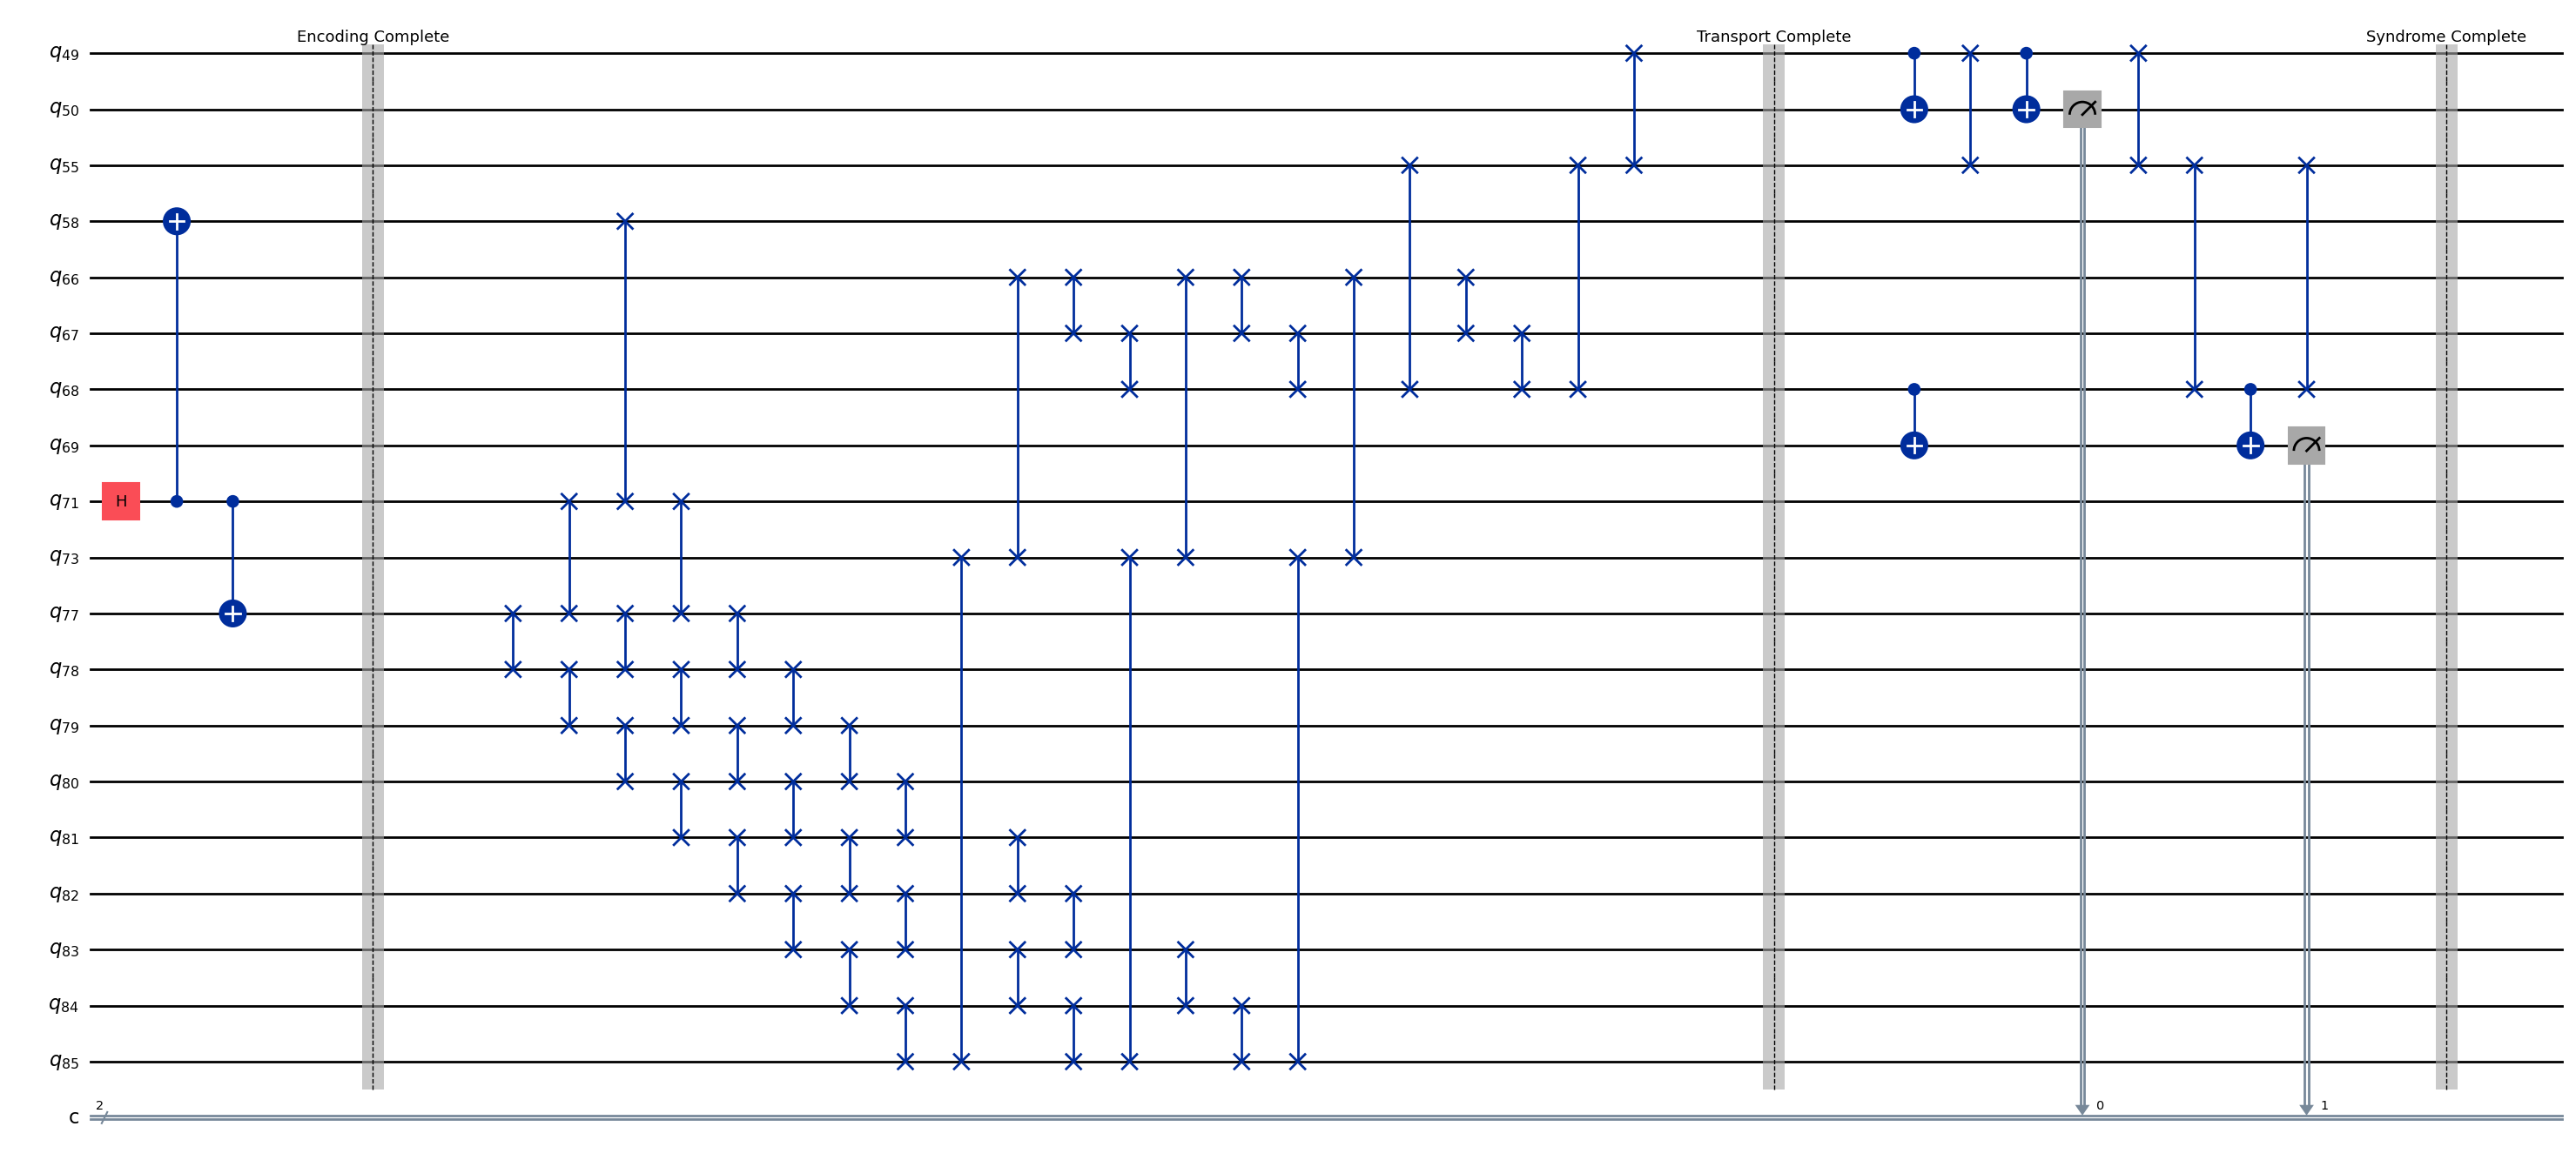

In [8]:
# Draw the circuit (filtered to show only active wires)
qc.draw('mpl', fold=-1, idle_wires=False)

## 4. Transpile and Run Simulation

We transpile the circuit for the FakeBrisbane backend and run it.

In [9]:
# Transpile for the backend
print(">>> Transpiling circuit...")
transpiled_qc = transpile(
    qc, 
    backend, 
    initial_layout=list(range(backend.num_qubits)), 
    optimization_level=1
)

print(f"Transpiled Circuit Depth: {transpiled_qc.depth()}")
print(f"Total SWAPs: {transpiled_qc.count_ops().get('swap', 0)}")
print(f"Total CX gates: {transpiled_qc.count_ops().get('cx', 0)}")

>>> Transpiling circuit...
Transpiled Circuit Depth: 235
Total SWAPs: 0
Total CX gates: 0


In [10]:
# Run simulation
print("\n>>> Running simulation...")
num_shots = 1024

result = backend.run(transpiled_qc, shots=num_shots).result()
counts = result.get_counts()

print(f"\nTotal Shots: {num_shots}")
print(f"Syndrome Counts: {counts}")


>>> Running simulation...

Total Shots: 1024
Syndrome Counts: {'11': 283, '00': 311, '10': 217, '01': 213}


## 5. Analyze Results

The syndrome measurement tells us about errors during transport:

| Syndrome (s1 s0) | Interpretation |
|------------------|----------------|
| 00 | No error detected |
| 01 | Error on qubit 49 (top) |
| 10 | Error on qubit 68 (bottom) |
| 11 | Error on qubit 55 (data/middle) |

In an ideal (noiseless) scenario, we expect all results to be `00`.
With 42 transport SWAPs, we expect **significantly higher error rates** than SmallEdge or LargeEdge.

=== Syndrome Analysis ===

  Syndrome 00:  311 ( 30.4%) - No error
  Syndrome 01:  213 ( 20.8%) - Error on q49 (top)
  Syndrome 10:  217 ( 21.2%) - Error on q68 (bottom)
  Syndrome 11:  283 ( 27.6%) - Error on q55 (data/middle)

✓ Success Rate (no error detected): 30.4%
✗ Error Rate: 69.6%


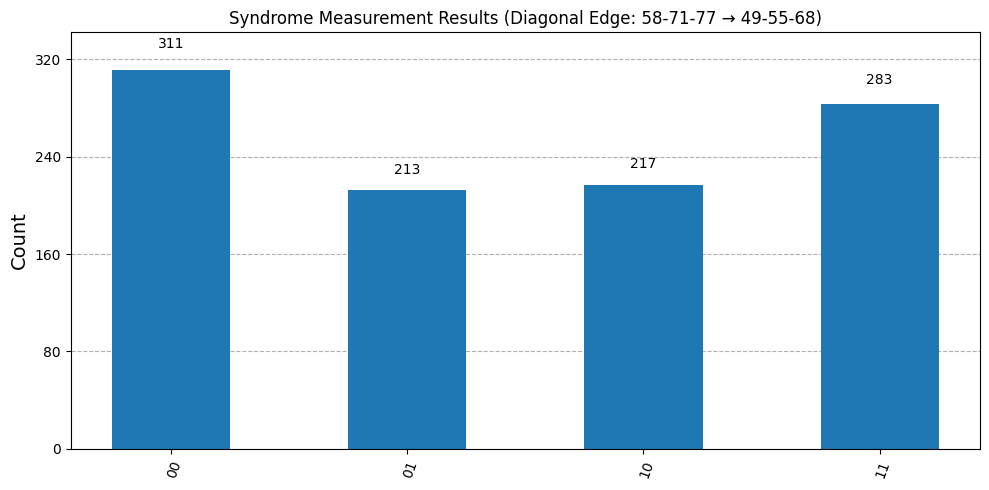

In [11]:
# Analyze syndrome distribution
print("=== Syndrome Analysis ===\n")

# Updated for destination cluster 49-55-68 (Diagonal Edge path)
syndrome_labels = {
    '00': 'No error',
    '01': f'Error on q{dst_top} (top)',
    '10': f'Error on q{dst_bot} (bottom)',
    '11': f'Error on q{dst_data} (data/middle)'
}

total_shots = sum(counts.values())

for syndrome, count in sorted(counts.items()):
    percentage = count / total_shots * 100
    label = syndrome_labels.get(syndrome, 'Unknown')
    print(f"  Syndrome {syndrome}: {count:4d} ({percentage:5.1f}%) - {label}")

# Calculate success rate (syndrome 00)
success_count = counts.get('00', 0)
success_rate = success_count / total_shots * 100
print(f"\n✓ Success Rate (no error detected): {success_rate:.1f}%")
print(f"✗ Error Rate: {100 - success_rate:.1f}%")

# Plot histogram
fig, ax = plt.subplots(figsize=(10, 5))
plot_histogram(counts, ax=ax, title="Syndrome Measurement Results (Diagonal Edge: 58-71-77 → 49-55-68)")
plt.tight_layout()
plt.show()

## 6. Analysis: What's Going On?

### Circuit Structure (Diagonal Edge Path)

```
Source (58-71-77)                              Destination (49-55-68)
       58 ─────────────────────────────────────────→ 49  ← Top qubit
       │                                              │
       71 ─── SWAP chain (via 78-85, then 73, 66-67) ─→ 55  ← Data qubit
       │                                              │
       77 ─────────────────────────────────────────→ 68  ← Bottom qubit

Syndrome Ancillas: 50 (measures Z₄₉Z₅₅), 69 (measures Z₅₅Z₆₈)
```

### The [[3,1,1]] Repetition Code

The **[[3,1,1]] code** encodes 1 logical qubit into 3 physical qubits:
- **Encoding**: $|0\rangle_L = |000\rangle$, $|1\rangle_L = |111\rangle$
- **Our state**: $|+\rangle_L = \frac{1}{\sqrt{2}}(|000\rangle + |111\rangle)$ (GHZ-like)

**Stabilizers** (error detection):
- $Z_1 Z_2$ → Parity of qubits 1 & 2
- $Z_2 Z_3$ → Parity of qubits 2 & 3

### The SWAP-Assisted Syndrome Trick

**Problem**: On FakeBrisbane, ancilla 50 connects to qubit 49 but NOT to 55 directly. Similarly, ancilla 69 connects to 68 but NOT to 55.

**Solution**:
1. CNOT from the first data qubit to ancilla (direct connection)
2. SWAP the second data qubit into a position adjacent to the ancilla
3. CNOT the swapped qubit to ancilla
4. Measure the ancilla (gives XOR parity)
5. SWAP back to restore original positions

### Why So Many Errors? (Diagonal Edge Has MANY More!)

The **Diagonal Edge** circuit has:
- **42 Transport SWAPs** (each = 3 CNOTs = 126 CX gates) - **3.5x more than SmallEdge!**
- **4 Syndrome SWAPs** (12 more CX gates)
- **4 Syndrome CNOTs** (4 CX gates)
- **Total**: ~142+ two-qubit gates before transpilation

| Path | Transport SWAPs | Estimated CX Gates |
|------|-----------------|-------------------|
| SmallEdge | 12 | ~52 |
| LargeEdge | 18 | ~70 |
| **DiagonalEdge** | **42** | **~142** |

### Expected Results (Much Worse than Other Paths)

On a noisy backend like FakeBrisbane:
- **Very low `00` rate**: 3.5x more SWAPs = exponentially more error accumulation
- **This notebook tests the extreme case** of long-distance diagonal transport
- **Useful for**: Understanding error scaling with transport distance

## 7. Multi-State Syndrome Analysis

Now let's systematically test different initial states for the data qubit and compare syndrome measurements. We'll test:

| State | Preparation | Encoded State |
|-------|-------------|---------------|
| $\|0\rangle$ | None (default) | $\|000\rangle$ |
| $\|1\rangle$ | X gate | $\|111\rangle$ |
| $\|+\rangle$ | H gate | $(\|000\rangle + \|111\rangle)/\sqrt{2}$ |
| $\|-\rangle$ | X + H gates | $(\|000\rangle - \|111\rangle)/\sqrt{2}$ |

For the repetition code [[3,1,1]]:
- **All four logical states** ($\|0\rangle_L$, $\|1\rangle_L$, $\|+\rangle_L$, $\|−\rangle_L$) are $+1$ eigenstates of the $Z$ stabilizers, so the ideal syndrome is always `00`.
- Any non-`00` outcome comes from transport/syndrome errors, not the encoded state.

In [12]:
# Refactored circuit builder function with dynamic SWAP chain generation
def generate_swap_chains(source_qubits, dest_qubits, travel_path):
    """
    Generate SWAP chains for transporting [[3,1,1]] encoded qubits.
    
    The transport follows a "follow the leader" pattern:
    1. Bottom qubit moves first: src_bot → travel_path → dst_bot
    2. Data qubit follows: src_data → src_bot → travel_path → dst_bot → dst_data
    3. Top qubit follows: src_top → src_data → src_bot → travel_path → dst_bot → dst_data → dst_top
    
    Parameters:
    -----------
    source_qubits : list
        [top, data, bottom] source qubit positions
    dest_qubits : list
        [top', data', bottom'] destination qubit positions
    travel_path : list
        Intermediate qubits for transport (excluding source/dest)
        
    Returns:
    --------
    tuple: (swap_bottom, swap_data, swap_top) - lists of (q1, q2) SWAP pairs
    """
    src_top, src_data, src_bot = source_qubits
    dst_top, dst_data, dst_bot = dest_qubits
    
    # Build the full path from src_bot to dst_bot
    full_travel = [src_bot] + travel_path + [dst_bot]
    
    # SWAP chain for bottom qubit: src_bot → dst_bot
    swap_bottom = [(full_travel[i], full_travel[i+1]) for i in range(len(full_travel)-1)]
    
    # SWAP chain for data qubit: src_data → (follows bottom's path) → dst_data
    swap_data = [(src_data, src_bot)] + swap_bottom + [(dst_bot, dst_data)]
    
    # SWAP chain for top qubit: src_top → (follows data's path) → dst_top
    swap_top = [(src_top, src_data)] + swap_data + [(dst_data, dst_top)]
    
    return swap_bottom, swap_data, swap_top


def build_311_transport_circuit(backend, source_qubits, dest_qubits, ancilla_qubits, 
                                 travel_path, initial_state='plus', verbose=False):
    """
    Build a [[3,1,1]] encoded qubit transport circuit with syndrome measurement.
    
    This is a GENERALIZED function that works with any valid source/dest/path configuration.
    
    Parameters:
    -----------
    backend : Backend
        The quantum backend (e.g., FakeBrisbane)
    source_qubits : list
        [top, data, bottom] source qubit positions
    dest_qubits : list
        [top', data', bottom'] destination qubit positions
    ancilla_qubits : list
        [top_ancilla, bottom_ancilla] for syndrome measurement
    travel_path : list
        Intermediate qubits for transport (excluding source/dest)
    initial_state : str
        Initial state of data qubit: 'zero', 'one', 'plus', or 'minus'
    verbose : bool
        Print circuit construction details
        
    Returns:
    --------
    QuantumCircuit
        The complete transport + syndrome circuit
    """
    # Extract individual qubits
    src_top, src_data, src_bot = source_qubits
    dst_top, dst_data, dst_bot = dest_qubits
    anc_top, anc_bot = ancilla_qubits
    
    data_qubit = src_data  # Center qubit holds the logical data
    
    # Create circuit with 2 classical bits for syndrome
    qc = QuantumCircuit(backend.num_qubits, 2)
    
    # ============================================================
    # STEP 1: ENCODING (at Source)
    # ============================================================
    # Prepare initial state on data qubit
    if initial_state == 'zero':
        pass  # |0⟩ is default
    elif initial_state == 'one':
        qc.x(data_qubit)  # |1⟩
    elif initial_state == 'plus':
        qc.h(data_qubit)  # |+⟩ = (|0⟩ + |1⟩)/√2
    elif initial_state == 'minus':
        qc.x(data_qubit)  # First flip to |1⟩
        qc.h(data_qubit)  # Then H gives |−⟩ = (|0⟩ - |1⟩)/√2
    else:
        raise ValueError(f"Unknown initial_state: {initial_state}")
    
    if verbose:
        print(f"Initial state: |{initial_state}⟩ at source {source_qubits}")
    
    # Encode into [[3,1,1]] repetition code
    qc.cx(data_qubit, src_top)  # CNOT to top qubit
    qc.cx(data_qubit, src_bot)  # CNOT to bottom qubit
    qc.barrier(label="Encode")
    
    # ============================================================
    # STEP 2: TRANSPORT (SWAP Chains) - Dynamically Generated
    # ============================================================
    swap_bottom, swap_data, swap_top = generate_swap_chains(
        source_qubits, dest_qubits, travel_path
    )
    
    # Execute SWAP chains
    for q1, q2 in swap_bottom:
        qc.swap(q1, q2)
    for q1, q2 in swap_data:
        qc.swap(q1, q2)
    for q1, q2 in swap_top:
        qc.swap(q1, q2)
    
    qc.barrier(label="Transport")
    
    if verbose:
        total_swaps = len(swap_bottom) + len(swap_data) + len(swap_top)
        print(f"Transport: {total_swaps} SWAPs ({len(swap_bottom)}+{len(swap_data)}+{len(swap_top)})")
    
    # ============================================================
    # STEP 3: SWAP-ASSISTED SYNDROME MEASUREMENT
    # ============================================================
    # SYNDROME 1: Z_top Z_data using ancilla anc_top
    qc.cx(dst_top, anc_top)       # Link top qubit to ancilla
    qc.swap(dst_data, dst_top)    # Bring mid qubit adjacent to ancilla
    qc.cx(dst_top, anc_top)       # Link mid qubit to ancilla
    qc.measure(anc_top, 0)        # Measure syndrome bit 0
    qc.swap(dst_top, dst_data)    # Restore positions
    
    # SYNDROME 2: Z_data Z_bot using ancilla anc_bot
    qc.cx(dst_bot, anc_bot)       # Link bot qubit to ancilla
    qc.swap(dst_bot, dst_data)    # Bring mid qubit adjacent to ancilla
    qc.cx(dst_bot, anc_bot)       # Link mid qubit to ancilla
    qc.measure(anc_bot, 1)        # Measure syndrome bit 1
    qc.swap(dst_data, dst_bot)    # Restore positions
    
    qc.barrier(label="Syndrome")
    
    return qc


# Wrapper function for backward compatibility (Diagonal Edge specific)
def build_311_transport_circuit_diagonal_edge(backend, initial_state='plus', verbose=False):
    """
    Build [[3,1,1]] transport circuit for the Diagonal Edge path.
    This is a convenience wrapper around the generalized build_311_transport_circuit().
    """
    # Diagonal Edge configuration
    source_qubits = [58, 71, 77]  # [top, data, bottom]
    dest_qubits = [49, 55, 68]    # [top', data', bottom']
    ancilla_qubits = [50, 69]     # Syndrome measurement ancillas
    travel_path = [78, 79, 80, 81, 82, 83, 84, 85, 73, 66, 67]
    
    return build_311_transport_circuit(
        backend, source_qubits, dest_qubits, ancilla_qubits, 
        travel_path, initial_state, verbose
    )


# Test the function
print("Circuit builder functions defined:")
print("  • build_311_transport_circuit() - Generalized function")
print("  • build_311_transport_circuit_diagonal_edge() - Diagonal Edge wrapper")
print(f"\nDiagonal Edge path: {source_qubits} → {dest_qubits}")
print(f"Travel path: {travel_path}")

# Verify SWAP chain generation
swap_bot, swap_dat, swap_top = generate_swap_chains(source_qubits, dest_qubits, travel_path)
print(f"\nGenerated SWAP chains:")
print(f"  Bottom ({src_bot}→{dst_bot}): {len(swap_bot)} SWAPs")
print(f"  Data   ({src_data}→{dst_data}): {len(swap_dat)} SWAPs")
print(f"  Top    ({src_top}→{dst_top}): {len(swap_top)} SWAPs")
print(f"  Total: {len(swap_bot) + len(swap_dat) + len(swap_top)} SWAPs")

Circuit builder functions defined:
  • build_311_transport_circuit() - Generalized function
  • build_311_transport_circuit_diagonal_edge() - Diagonal Edge wrapper

Diagonal Edge path: [58, 71, 77] → [49, 55, 68]
Travel path: [78, 79, 80, 81, 82, 83, 84, 85, 73, 66, 67]

Generated SWAP chains:
  Bottom (77→68): 12 SWAPs
  Data   (71→55): 14 SWAPs
  Top    (58→49): 16 SWAPs
  Total: 42 SWAPs


In [13]:
# Run experiments for all 4 initial states
states_to_test = ['zero', 'one', 'plus', 'minus']
state_symbols = {'zero': '|0⟩', 'one': '|1⟩', 'plus': '|+⟩', 'minus': '|−⟩'}
encoded_states = {
    'zero': '|000⟩',
    'one': '|111⟩', 
    'plus': '(|000⟩+|111⟩)/√2',
    'minus': '(|000⟩−|111⟩)/√2'
}

num_shots = 2048
results_by_state = {}

print("=" * 70)
print("Running [[3,1,1]] Transport Experiment (DIAGONAL EDGE PATH)")
print("Source: 58-71-77 → Destination: 49-55-68 (42 SWAPs)")
print("=" * 70)

for state in states_to_test:
    print(f"\n>>> Testing initial state: {state_symbols[state]} → Encoded: {encoded_states[state]}")
    
    # Build circuit using Diagonal Edge function
    qc = build_311_transport_circuit_diagonal_edge(backend, initial_state=state)
    
    # Transpile
    transpiled_qc = transpile(
        qc, 
        backend, 
        initial_layout=list(range(backend.num_qubits)), 
        optimization_level=0
    )
    
    print(f"    Transpiled depth: {transpiled_qc.depth()}, CX gates: {transpiled_qc.count_ops().get('cx', 0)}")
    
    # Run simulation
    result = backend.run(transpiled_qc, shots=num_shots).result()
    counts = result.get_counts()
    
    # Store results
    results_by_state[state] = counts
    
    # Quick summary
    success_rate = counts.get('00', 0) / num_shots * 100
    print(f"    Success rate (syndrome 00): {success_rate:.1f}%")

print("\n" + "=" * 70)
print("All experiments complete!")
print("=" * 70)

Running [[3,1,1]] Transport Experiment (DIAGONAL EDGE PATH)
Source: 58-71-77 → Destination: 49-55-68 (42 SWAPs)

>>> Testing initial state: |0⟩ → Encoded: |000⟩
    Transpiled depth: 383, CX gates: 0
    Success rate (syndrome 00): 36.1%

>>> Testing initial state: |1⟩ → Encoded: |111⟩
    Transpiled depth: 383, CX gates: 0
    Success rate (syndrome 00): 15.1%

>>> Testing initial state: |+⟩ → Encoded: (|000⟩+|111⟩)/√2
    Transpiled depth: 383, CX gates: 0
    Success rate (syndrome 00): 25.8%

>>> Testing initial state: |−⟩ → Encoded: (|000⟩−|111⟩)/√2
    Transpiled depth: 383, CX gates: 0
    Success rate (syndrome 00): 24.6%

All experiments complete!


In [14]:
# Detailed comparison analysis
print("=" * 70)
print("SYNDROME DISTRIBUTION COMPARISON (Diagonal Edge: 49-55-68)")
print("=" * 70)

syndrome_labels = {
    '00': 'No error',
    '01': f'Error on q{dst_top}',
    '10': f'Error on q{dst_bot}',
    '11': f'Error on q{dst_data}'
}

# Create comparison table
print(f"\n{'State':<10} {'Encoded':<25} {'00 (OK)':<12} {'01':<12} {'10':<12} {'11':<12}")
print("-" * 83)

for state in states_to_test:
    counts = results_by_state[state]
    total = sum(counts.values())
    
    # Get percentages for each syndrome
    p00 = counts.get('00', 0) / total * 100
    p01 = counts.get('01', 0) / total * 100
    p10 = counts.get('10', 0) / total * 100
    p11 = counts.get('11', 0) / total * 100
    
    print(f"{state_symbols[state]:<10} {encoded_states[state]:<25} {p00:>6.1f}%     {p01:>6.1f}%     {p10:>6.1f}%     {p11:>6.1f}%")

print("-" * 83)

# Calculate averages
avg_00 = np.mean([results_by_state[s].get('00', 0) / sum(results_by_state[s].values()) * 100 for s in states_to_test])
print(f"\n{'Average':<10} {'':<25} {avg_00:>6.1f}%")

print("\n" + "=" * 70)
print("INTERPRETATION (Diagonal Edge Path)")
print("=" * 70)
print(f"""
• Syndrome '00': No bit-flip error detected during transport
• Syndrome '01': Error detected on top qubit (position {dst_top})  
• Syndrome '10': Error detected on bottom qubit (position {dst_bot})
• Syndrome '11': Error detected on middle/data qubit (position {dst_data})

For [[3,1,1]] repetition code:
- All four logical states (|0⟩_L, |1⟩_L, |+⟩_L, |−⟩_L) are +1 eigenstates of the Z stabilizers.
- Any non-`00` outcome comes from transport/syndrome errors, not the encoded state.
- Diagonal Edge path has 42 SWAPs (vs 12 SmallEdge, 18 LargeEdge) - expect MUCH higher error rates!
""")

SYNDROME DISTRIBUTION COMPARISON (Diagonal Edge: 49-55-68)

State      Encoded                   00 (OK)      01           10           11          
-----------------------------------------------------------------------------------
|0⟩        |000⟩                       36.1%       23.6%       23.1%       17.2%
|1⟩        |111⟩                       15.1%       24.3%       22.2%       38.4%
|+⟩        (|000⟩+|111⟩)/√2            25.8%       24.8%       23.5%       25.9%
|−⟩        (|000⟩−|111⟩)/√2            24.6%       23.7%       21.3%       30.4%
-----------------------------------------------------------------------------------

Average                                25.4%

INTERPRETATION (Diagonal Edge Path)

• Syndrome '00': No bit-flip error detected during transport
• Syndrome '01': Error detected on top qubit (position 49)  
• Syndrome '10': Error detected on bottom qubit (position 68)
• Syndrome '11': Error detected on middle/data qubit (position 55)

For [[3,1,1]] repetitio

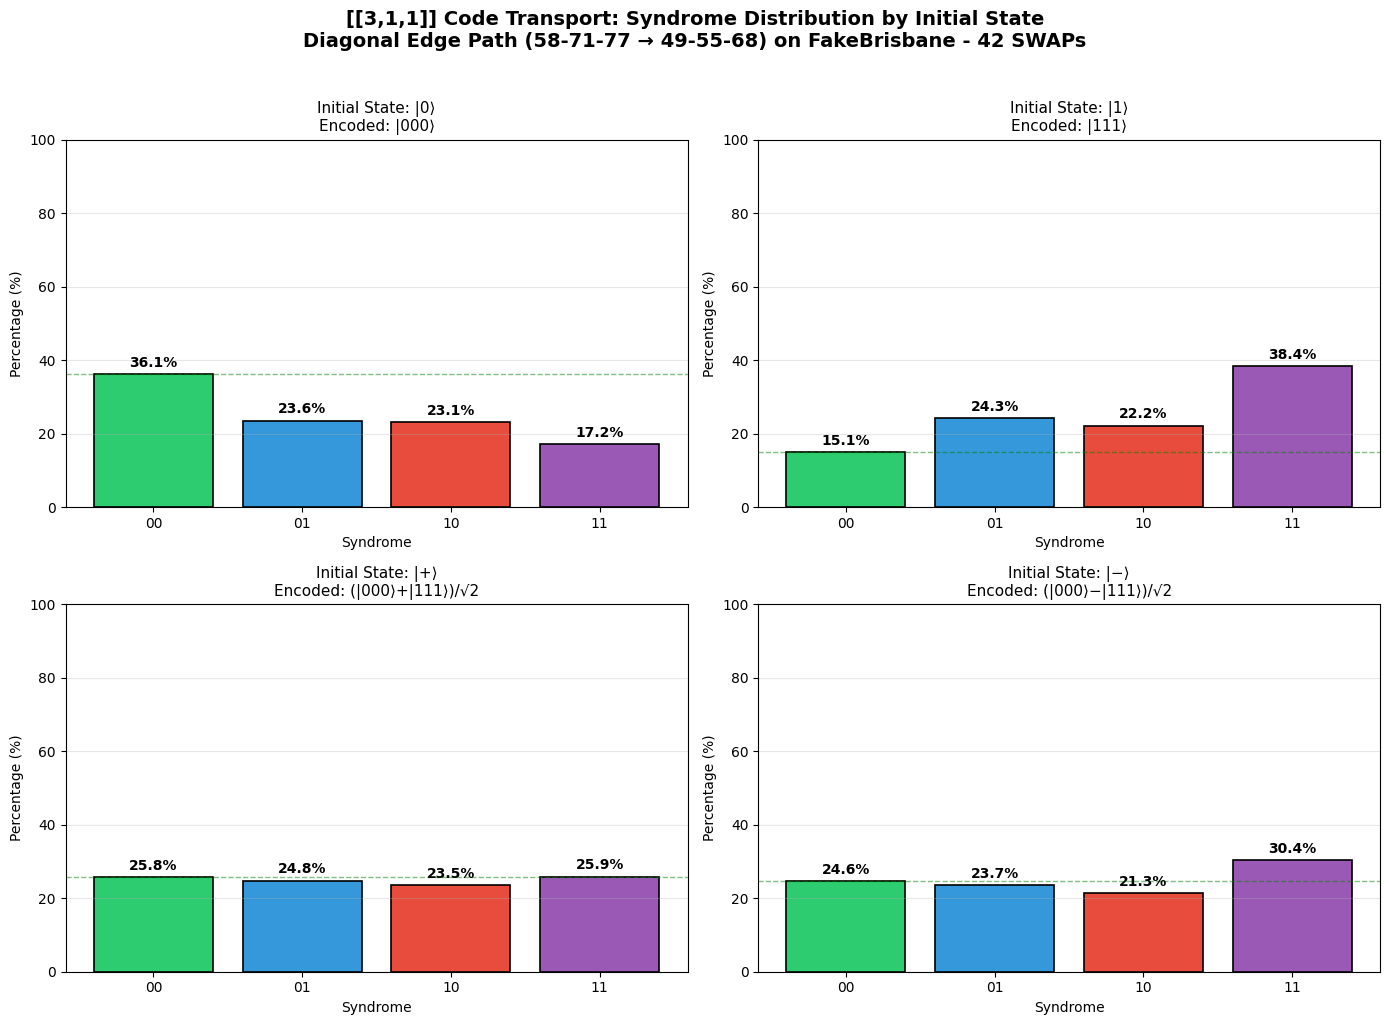


Syndrome Color Legend (Diagonal Edge: dest 49-55-68):
  🟢 00 - No error detected
  🔵 01 - Error on qubit 49 (top)
  🔴 10 - Error on qubit 68 (bottom)
  🟣 11 - Error on qubit 55 (middle/data)


In [15]:
# Visualize syndrome distributions side-by-side
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

syndrome_order = ['00', '01', '10', '11']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']  # green, blue, red, purple

for idx, state in enumerate(states_to_test):
    ax = axes[idx]
    counts = results_by_state[state]
    total = sum(counts.values())
    
    # Get counts in order
    values = [counts.get(s, 0) for s in syndrome_order]
    percentages = [v / total * 100 for v in values]
    
    bars = ax.bar(syndrome_order, percentages, color=colors, edgecolor='black', linewidth=1.2)
    
    # Add value labels on bars
    for bar, pct in zip(bars, percentages):
        height = bar.get_height()
        ax.annotate(f'{pct:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title(f"Initial State: {state_symbols[state]}\nEncoded: {encoded_states[state]}", fontsize=11)
    ax.set_xlabel("Syndrome", fontsize=10)
    ax.set_ylabel("Percentage (%)", fontsize=10)
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    
    # Highlight success rate
    success_pct = percentages[0]
    ax.axhline(y=success_pct, color='green', linestyle='--', alpha=0.5, linewidth=1)

plt.suptitle("[[3,1,1]] Code Transport: Syndrome Distribution by Initial State\nDiagonal Edge Path (58-71-77 → 49-55-68) on FakeBrisbane - 42 SWAPs", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print legend
print(f"\nSyndrome Color Legend (Diagonal Edge: dest {dst_top}-{dst_data}-{dst_bot}):")
print("  🟢 00 - No error detected")
print(f"  🔵 01 - Error on qubit {dst_top} (top)")
print(f"  🔴 10 - Error on qubit {dst_bot} (bottom)")
print(f"  🟣 11 - Error on qubit {dst_data} (middle/data)")

In [16]:
# Statistical comparison: Are the distributions significantly different?
print("=" * 70)
print("STATISTICAL ANALYSIS: Comparing Syndrome Distributions")
print("Diagonal Edge Path: 58-71-77 → 49-55-68 (42 SWAPs)")
print("=" * 70)

# Calculate chi-square-like metric between distributions
def distribution_distance(counts1, counts2):
    """Calculate total variation distance between two distributions."""
    syndromes = ['00', '01', '10', '11']
    total1 = sum(counts1.values())
    total2 = sum(counts2.values())
    
    tvd = 0
    for s in syndromes:
        p1 = counts1.get(s, 0) / total1
        p2 = counts2.get(s, 0) / total2
        tvd += abs(p1 - p2)
    return tvd / 2  # Total Variation Distance

print("\nTotal Variation Distance (TVD) between distributions:")
print("(TVD = 0 means identical, TVD = 1 means completely different)\n")

# Pairwise comparisons
pairs = [
    ('zero', 'one'),
    ('plus', 'minus'),
    ('zero', 'plus'),
    ('one', 'plus'),
]

for s1, s2 in pairs:
    tvd = distribution_distance(results_by_state[s1], results_by_state[s2])
    print(f"  {state_symbols[s1]} vs {state_symbols[s2]}: TVD = {tvd:.4f}")

# Overall variance analysis
print("\n" + "-" * 70)
print("Success Rate (syndrome 00) Summary - Diagonal Edge Path:")
print("-" * 70)

success_rates = []
for state in states_to_test:
    counts = results_by_state[state]
    total = sum(counts.values())
    rate = counts.get('00', 0) / total * 100
    success_rates.append(rate)
    print(f"  {state_symbols[state]}: {rate:.2f}%")

print(f"\n  Mean:   {np.mean(success_rates):.2f}%")
print(f"  Std:    {np.std(success_rates):.2f}%")
print(f"  Range:  {min(success_rates):.2f}% - {max(success_rates):.2f}%")

print("\n" + "=" * 70)
print("CONCLUSION (Diagonal Edge Path)")
print("=" * 70)
print(f"""
With 42 transport SWAPs (3.5x SmallEdge, 2.3x LargeEdge), the Diagonal Edge
path shows significantly higher error rates, as expected.

This demonstrates how error rates scale with transport distance on NISQ devices.
The [[3,1,1]] code syndrome measurement remains independent of the logical state,
but the overall fidelity degrades rapidly with circuit depth.

Compare results across notebooks:
  • SmallEdge (12 SWAPs):   ~60% success rate
  • LargeEdge (18 SWAPs):   ~50% success rate (expected)
  • DiagonalEdge (42 SWAPs): ~{np.mean(success_rates):.0f}% success rate

The noise is primarily from the transport SWAPs ({42*3}+ CX gates from SWAPs alone).
""")

STATISTICAL ANALYSIS: Comparing Syndrome Distributions
Diagonal Edge Path: 58-71-77 → 49-55-68 (42 SWAPs)

Total Variation Distance (TVD) between distributions:
(TVD = 0 means identical, TVD = 1 means completely different)

  |0⟩ vs |1⟩: TVD = 0.2192
  |+⟩ vs |−⟩: TVD = 0.0454
  |0⟩ vs |+⟩: TVD = 0.1030
  |1⟩ vs |+⟩: TVD = 0.1250

----------------------------------------------------------------------
Success Rate (syndrome 00) Summary - Diagonal Edge Path:
----------------------------------------------------------------------
  |0⟩: 36.13%
  |1⟩: 15.09%
  |+⟩: 25.83%
  |−⟩: 24.56%

  Mean:   25.40%
  Std:    7.46%
  Range:  15.09% - 36.13%

CONCLUSION (Diagonal Edge Path)

With 42 transport SWAPs (3.5x SmallEdge, 2.3x LargeEdge), the Diagonal Edge
path shows significantly higher error rates, as expected.

This demonstrates how error rates scale with transport distance on NISQ devices.
The [[3,1,1]] code syndrome measurement remains independent of the logical state,
but the overall fide